In [2]:
# ============================================================
# ROBUST PATH FIX
# ============================================================
import os
from pathlib import Path

try:
    project_root = Path(__file__).parent.parent
except NameError:
    cwd = Path(os.getcwd())
    project_root = cwd.parent if cwd.name == "notebooks" else cwd

os.chdir(project_root)
print(f"Working directory set to: {os.getcwd()}")
# ============================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

sns.set_theme(style="whitegrid")

file_path = "data/processed/tracts_acs_wind_2024_expanded.parquet"

print("=" * 70)
print("Modeling: Logistic Regression (with Missing Value Handling)")
print("=" * 70)

# ============================================================
# 1. LOAD DATA + DROP MISSING VALUES
# ============================================================

df = pd.read_parquet(file_path)
print(f"Original data: {len(df):,} tracts")

# Select features and target, then drop any rows with missing values
feature_cols = [
    "total_population",
    "total_housing_units",
    "median_household_income",
    "median_home_value",
    "housing_built_2010_or_later",
    "housing_built_before_2000"
]

df_model = df[feature_cols + ["has_wind_farm"]].dropna()
print(f"After dropping missing values: {len(df_model):,} tracts")

X = df_model[feature_cols]
y = df_model["has_wind_farm"]

print(f"\nTarget distribution:\n{y.value_counts(normalize=True).round(3)}")

# ============================================================
# 2. TRAIN / TEST SPLIT + SCALING
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set: {len(X_train):,}")
print(f"Test set:     {len(X_test):,}")

# ============================================================
# 3. TRAIN LOGISTIC REGRESSION
# ============================================================

model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)
print("\nModel training complete.")

# ============================================================
# 4. EVALUATION
# ============================================================

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("\n" + "=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.3f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=["No Wind Farm", "Has Wind Farm"]))

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

# ============================================================
# 5. FEATURE IMPORTANCE
# ============================================================

coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": model.coef_[0],
    "Odds Ratio": np.exp(model.coef_[0])
}).sort_values("Coefficient", ascending=False)

print("\n--- Feature Importance ---")
print(coef_df.round(3))

print("=" * 70)

Working directory set to: /Users/jakemammen/Library/CloudStorage/OneDrive-Personal/Desktop/windfarm_socioecon_geospatial_analysis
Modeling: Logistic Regression (with Missing Value Handling)
Original data: 8,985 tracts
After dropping missing values: 8,518 tracts

Target distribution:
has_wind_farm
0    0.957
1    0.043
Name: proportion, dtype: float64

Training set: 6,388
Test set:     2,130

Model training complete.

MODEL PERFORMANCE

Accuracy: 0.703
ROC-AUC:  0.829

--- Classification Report ---
               precision    recall  f1-score   support

 No Wind Farm       0.99      0.70      0.82      2038
Has Wind Farm       0.11      0.80      0.19        92

     accuracy                           0.70      2130
    macro avg       0.55      0.75      0.50      2130
 weighted avg       0.95      0.70      0.79      2130


--- Confusion Matrix ---
[[1423  615]
 [  18   74]]

--- Feature Importance ---
                       Feature  Coefficient  Odds Ratio
2      median_household_inc

In [3]:
# ============================================================
# ROBUST PATH FIX
# ============================================================
import os
from pathlib import Path

try:
    project_root = Path(__file__).parent.parent
except NameError:
    cwd = Path(os.getcwd())
    project_root = cwd.parent if cwd.name == "notebooks" else cwd

os.chdir(project_root)
print(f"Working directory set to: {os.getcwd()}")
# ============================================================


import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

file_path = "data/processed/tracts_acs_wind_2024_expanded.parquet"

print("=" * 70)
print("Improving the Model: Feature Engineering + Logistic Regression")
print("=" * 70)

# ============================================================
# 1. LOAD DATA + CREATE NEW FEATURES
# ============================================================

df = pd.read_parquet(file_path)

# Create derived features
df["pct_recent_housing"] = df["housing_built_2010_or_later"] / (df["total_housing_units"] + 1)
df["housing_density"] = df["total_housing_units"] / (df["total_population"] + 1)
df["income_vs_home_value"] = df["median_household_income"] / (df["median_home_value"] + 1)

# Select final feature set (original + engineered)
feature_cols = [
    "total_population",
    "total_housing_units",
    "median_household_income",
    "median_home_value",
    "housing_built_2010_or_later",
    "housing_built_before_2000",
    "pct_recent_housing",
    "housing_density",
    "income_vs_home_value"
]

# Drop rows with missing values in selected features
df_model = df[feature_cols + ["has_wind_farm"]].dropna()

X = df_model[feature_cols]
y = df_model["has_wind_farm"]

print(f"Final modeling dataset: {len(df_model):,} tracts")
print(f"Features used: {feature_cols}")

# ============================================================
# 2. TRAIN / TEST SPLIT + SCALING
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# 3. TRAIN IMPROVED LOGISTIC REGRESSION
# ============================================================

model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

# ============================================================
# 4. EVALUATE AND COMPARE
# ============================================================

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("\n" + "=" * 50)
print("IMPROVED MODEL PERFORMANCE")
print("=" * 50)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.3f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=["No Wind Farm", "Has Wind Farm"]))

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

# ============================================================
# 5. NEW FEATURE IMPORTANCE
# ============================================================

coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": model.coef_[0],
    "Odds Ratio": np.exp(model.coef_[0])
}).sort_values("Coefficient", ascending=False)

print("\n--- Improved Feature Importance ---")
print(coef_df.round(3))

print("=" * 70)

Working directory set to: /Users/jakemammen/Library/CloudStorage/OneDrive-Personal/Desktop/windfarm_socioecon_geospatial_analysis
Improving the Model: Feature Engineering + Logistic Regression
Final modeling dataset: 8,518 tracts
Features used: ['total_population', 'total_housing_units', 'median_household_income', 'median_home_value', 'housing_built_2010_or_later', 'housing_built_before_2000', 'pct_recent_housing', 'housing_density', 'income_vs_home_value']

IMPROVED MODEL PERFORMANCE

Accuracy: 0.737
ROC-AUC:  0.830

--- Classification Report ---
               precision    recall  f1-score   support

 No Wind Farm       0.99      0.73      0.84      2038
Has Wind Farm       0.12      0.80      0.21        92

     accuracy                           0.74      2130
    macro avg       0.55      0.77      0.53      2130
 weighted avg       0.95      0.74      0.81      2130


--- Confusion Matrix ---
[[1495  543]
 [  18   74]]

--- Improved Feature Importance ---
                       

In [4]:
# ============================================================
# ROBUST PATH FIX
# ============================================================
import os
from pathlib import Path

try:
    project_root = Path(__file__).parent.parent
except NameError:
    cwd = Path(os.getcwd())
    project_root = cwd.parent if cwd.name == "notebooks" else cwd

os.chdir(project_root)
print(f"Working directory set to: {os.getcwd()}")
# ============================================================


import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

file_path = "data/processed/tracts_acs_wind_2024_expanded.parquet"

print("=" * 70)
print("Comparing Models: Logistic Regression vs HistGradientBoosting")
print("=" * 70)

# ============================================================
# 1. LOAD DATA + CREATE DERIVED FEATURES
# ============================================================

df = pd.read_parquet(file_path)

# Create engineered features
df["pct_recent_housing"] = df["housing_built_2010_or_later"] / (df["total_housing_units"] + 1)
df["housing_density"] = df["total_housing_units"] / (df["total_population"] + 1)
df["income_vs_home_value"] = df["median_household_income"] / (df["median_home_value"] + 1)

feature_cols = [
    "total_population",
    "total_housing_units",
    "median_household_income",
    "median_home_value",
    "housing_built_2010_or_later",
    "housing_built_before_2000",
    "pct_recent_housing",
    "housing_density",
    "income_vs_home_value"
]

# ============================================================
# 2. CREATE CLEAN VERSION (for Logistic Regression)
# ============================================================

df_clean = df[feature_cols + ["has_wind_farm"]].dropna()
print(f"Clean dataset (for Logistic Regression): {len(df_clean):,} tracts")

X_clean = df_clean[feature_cols]
y_clean = df_clean["has_wind_farm"]

# ============================================================
# 3. CREATE FULL VERSION (for HistGradientBoosting - keeps missing values)
# ============================================================

df_full = df[feature_cols + ["has_wind_farm"]].copy()
X_full = df_full[feature_cols]
y_full = df_full["has_wind_farm"]

print(f"Full dataset (for HistGradientBoosting): {len(df_full):,} tracts")

# ============================================================
# 4. LOGISTIC REGRESSION (using clean data)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.25, random_state=42, stratify=y_clean
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("\n" + "=" * 50)
print("LOGISTIC REGRESSION (Improved)")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.3f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_log):.3f}")

# ============================================================
# 5. HISTGRADIENTBOOSTING (using full data with missing values)
# ============================================================

X_train_hgb, X_test_hgb, y_train_hgb, y_test_hgb = train_test_split(
    X_full, y_full, test_size=0.25, random_state=42, stratify=y_full
)

hgb_model = HistGradientBoostingClassifier(
    class_weight="balanced",
    max_iter=200,
    learning_rate=0.1,
    random_state=42
)

hgb_model.fit(X_train_hgb, y_train_hgb)

y_pred_hgb = hgb_model.predict(X_test_hgb)
y_prob_hgb = hgb_model.predict_proba(X_test_hgb)[:, 1]

print("\n" + "=" * 50)
print("HISTGRADIENTBOOSTING CLASSIFIER")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test_hgb, y_pred_hgb):.3f}")
print(f"ROC-AUC:  {roc_auc_score(y_test_hgb, y_prob_hgb):.3f}")

print("\n--- Classification Report (HistGradientBoosting) ---")
print(classification_report(y_test_hgb, y_pred_hgb, target_names=["No Wind Farm", "Has Wind Farm"]))

print("\n--- Confusion Matrix (HistGradientBoosting) ---")
print(confusion_matrix(y_test_hgb, y_pred_hgb))

# ============================================================
# 6. FINAL COMPARISON
# ============================================================

print("\n" + "=" * 50)
print("MODEL COMPARISON SUMMARY")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>10} {'ROC-AUC':>10}")
print("-" * 55)
print(f"{'Logistic Regression (Improved)':<35} {accuracy_score(y_test, y_pred_log):>10.3f} {roc_auc_score(y_test, y_prob_log):>10.3f}")
print(f"{'HistGradientBoostingClassifier':<35} {accuracy_score(y_test_hgb, y_pred_hgb):>10.3f} {roc_auc_score(y_test_hgb, y_prob_hgb):>10.3f}")
print("=" * 55)

Working directory set to: /Users/jakemammen/Library/CloudStorage/OneDrive-Personal/Desktop/windfarm_socioecon_geospatial_analysis
Comparing Models: Logistic Regression vs HistGradientBoosting
Clean dataset (for Logistic Regression): 8,518 tracts
Full dataset (for HistGradientBoosting): 8,985 tracts

LOGISTIC REGRESSION (Improved)
Accuracy: 0.737
ROC-AUC:  0.830

HISTGRADIENTBOOSTING CLASSIFIER
Accuracy: 0.943
ROC-AUC:  0.829

--- Classification Report (HistGradientBoosting) ---
               precision    recall  f1-score   support

 No Wind Farm       0.97      0.97      0.97      2153
Has Wind Farm       0.30      0.28      0.29        94

     accuracy                           0.94      2247
    macro avg       0.63      0.62      0.63      2247
 weighted avg       0.94      0.94      0.94      2247


--- Confusion Matrix (HistGradientBoosting) ---
[[2092   61]
 [  68   26]]

MODEL COMPARISON SUMMARY
Model                                 Accuracy    ROC-AUC
------------------------

Working directory set to: /Users/jakemammen/Library/CloudStorage/OneDrive-Personal/Desktop/windfarm_socioecon_geospatial_analysis
Creating Professional Visualizations for Improved Logistic Regression


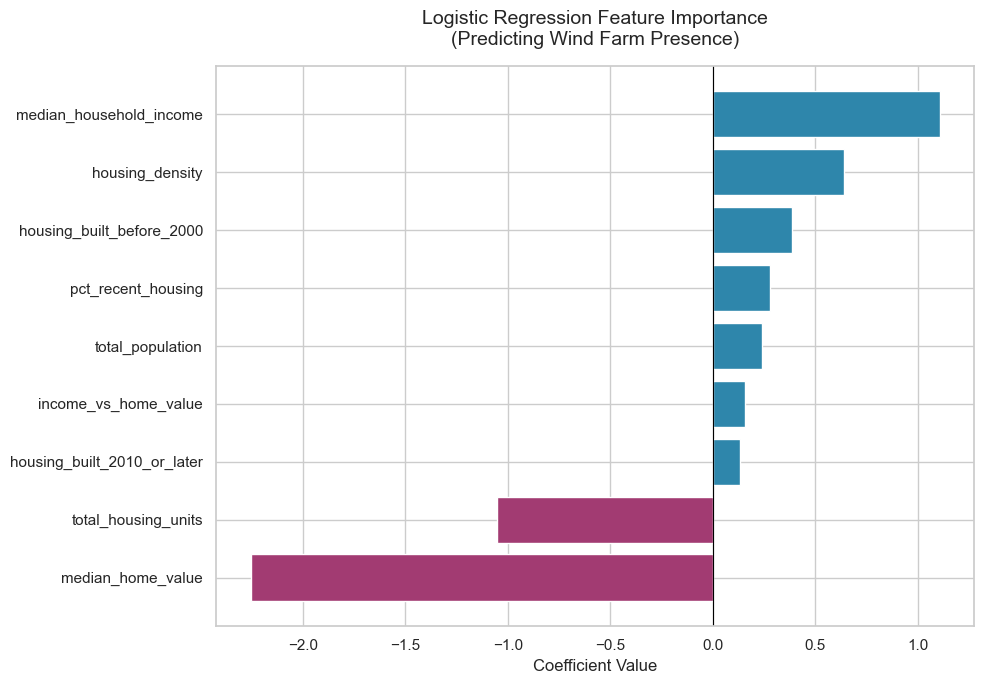

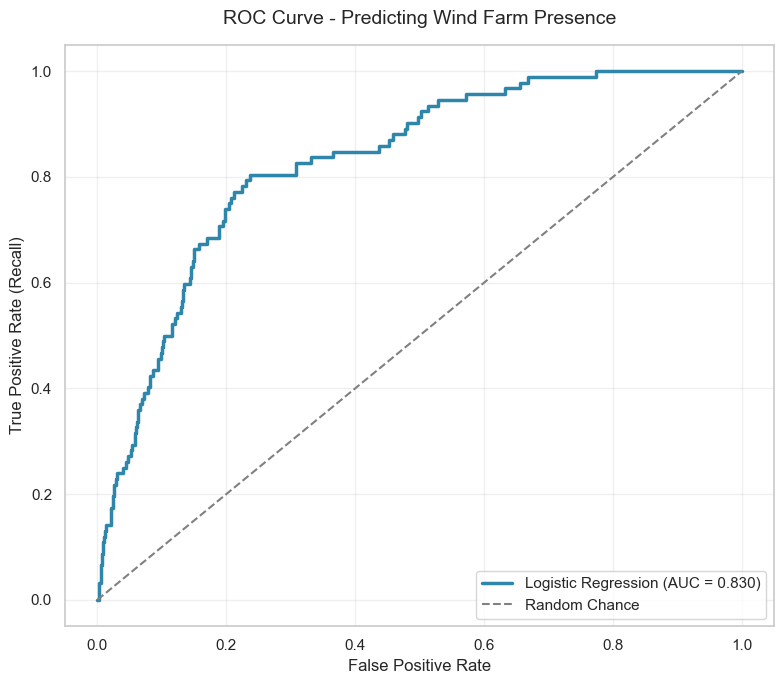

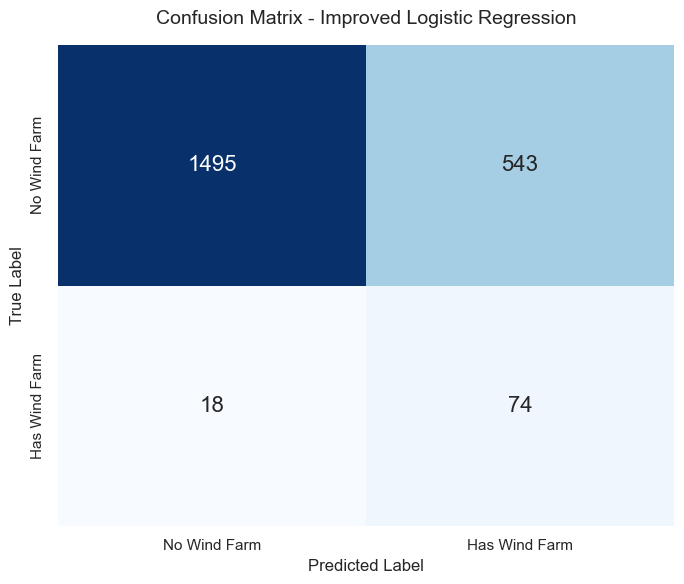

Visualizations complete.


In [6]:
# ============================================================
# ROBUST PATH FIX
# ============================================================
import os
from pathlib import Path

try:
    project_root = Path(__file__).parent.parent
except NameError:
    cwd = Path(os.getcwd())
    project_root = cwd.parent if cwd.name == "notebooks" else cwd

os.chdir(project_root)
print(f"Working directory set to: {os.getcwd()}")
# ============================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

file_path = "data/processed/tracts_acs_wind_2024_expanded.parquet"

print("=" * 70)
print("Creating Professional Visualizations for Improved Logistic Regression")
print("=" * 70)

# ============================================================
# 1. LOAD DATA + PREPARE MODEL (same as before)
# ============================================================

df = pd.read_parquet(file_path)

df["pct_recent_housing"] = df["housing_built_2010_or_later"] / (df["total_housing_units"] + 1)
df["housing_density"] = df["total_housing_units"] / (df["total_population"] + 1)
df["income_vs_home_value"] = df["median_household_income"] / (df["median_home_value"] + 1)

feature_cols = [
    "total_population",
    "total_housing_units",
    "median_household_income",
    "median_home_value",
    "housing_built_2010_or_later",
    "housing_built_before_2000",
    "pct_recent_housing",
    "housing_density",
    "income_vs_home_value"
]

df_model = df[feature_cols + ["has_wind_farm"]].dropna()

X = df_model[feature_cols]
y = df_model["has_wind_farm"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_prob = model.predict_proba(X_test_scaled)[:, 1]
y_pred = model.predict(X_test_scaled)

# ============================================================
# 2. VISUALIZATION 1: Feature Importance (Coefficients)
# ============================================================

coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": model.coef_[0]
}).sort_values("Coefficient", ascending=True)

plt.figure(figsize=(10, 7))
colors = ["#2E86AB" if c > 0 else "#A23B72" for c in coef_df["Coefficient"]]
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
plt.axvline(x=0, color="black", linewidth=0.8)
plt.xlabel("Coefficient Value", fontsize=12)
plt.title("Logistic Regression Feature Importance\n(Predicting Wind Farm Presence)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# ============================================================
# 3. VISUALIZATION 2: ROC Curve
# ============================================================

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, color="#2E86AB", linewidth=2.5, label=f"Logistic Regression (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1.5, label="Random Chance")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate (Recall)", fontsize=12)
plt.title("ROC Curve - Predicting Wind Farm Presence", fontsize=14, pad=15)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 4. VISUALIZATION 3: Confusion Matrix Heatmap
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Wind Farm", "Has Wind Farm"],
    yticklabels=["No Wind Farm", "Has Wind Farm"],
    cbar=False,
    annot_kws={"size": 16}
)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix - Improved Logistic Regression", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

print("=" * 70)
print("Visualizations complete.")
print("=" * 70)